In [5]:
from tdse_solutions import lemniscate_f
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.legend_handler import HandlerTuple, HandlerBase

In [14]:
class TupleOfLinesHandler(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):
        def get_style_props(l):
            color = l.get_color()
            lw = l.get_linewidth()
            marker = l.get_marker()
            linestyle = l.get_linestyle()
            return {'color' : color, 'linewidth' : lw, 'marker' : marker, 'linestyle' : linestyle}
        
        l1_0, l2_0 = orig_handle
        l1 = plt.Line2D([x0,y0+width], [0.9*height,0.9*height], 
                                                **get_style_props(l1_0))
        l2 = plt.Line2D([x0,y0+width], [0.1*height,0.1*height], **get_style_props(l2_0))
        return [l1, l2]

In [15]:
def alpha(t, eta, Omega, delta, psi):
    return (eta*Omega*np.exp(-1j*psi)/(2*delta)) * (np.exp(-1j*delta*t) - 1)

def rect_pulse(x):
    return 0.5*np.where(np.logical_and(x > 0, x < 1), 1, 0)

def echoed_rect_pulse(x):
    return math.sqrt(2)*(rect_pulse(2*x) - rect_pulse(2*x - 1))

def lemniscate_pulse(t):
    a = 0.7274788716591838
    A = 0.95778915

    x = A*np.where(np.logical_and(t > 0, t < 1), lemniscate_f(2*np.pi*t, a), 0)
    #y = np.where(np.logical_and(t > 0, t < 1), Omega_max*np.sin(2*np.pi*t)*(1 - a + a*np.cos(2*np.pi*t)), 0)

    return x

def echoed_lemniscate_pulse(t):
    return math.sqrt(2)*(lemniscate_pulse(2*t) - lemniscate_pulse(2*t - 1))

In [16]:
t_gate = 2*np.pi
t = np.linspace(0, t_gate, 2001)
t1 = np.arange(-2, 5, 1e-3)
n_t = t.size
n_mid = int((n_t - 1)/2)
t_arr_1 = t[:n_mid+1]
t_arr_2 = t[n_mid:]

eta = 1
Omega = 1
delta = 2*np.pi/t_gate
psi = 0
res_1 = np.array([alpha(t1, eta, Omega, delta, psi) for t1 in t])

a = 0.7274788716591838
Omega_max = 0.95778915
x_1 = Omega_max*(1 - np.cos(t))
y_1 = Omega_max*np.sin(t)*(1 - a + a*np.cos(t))

# f = lemniscate_f(t, a)
# f_1 = lemniscate_f(2*t_arr_1, a)
# f_2 = -lemniscate_f(2*t_arr_2, a)

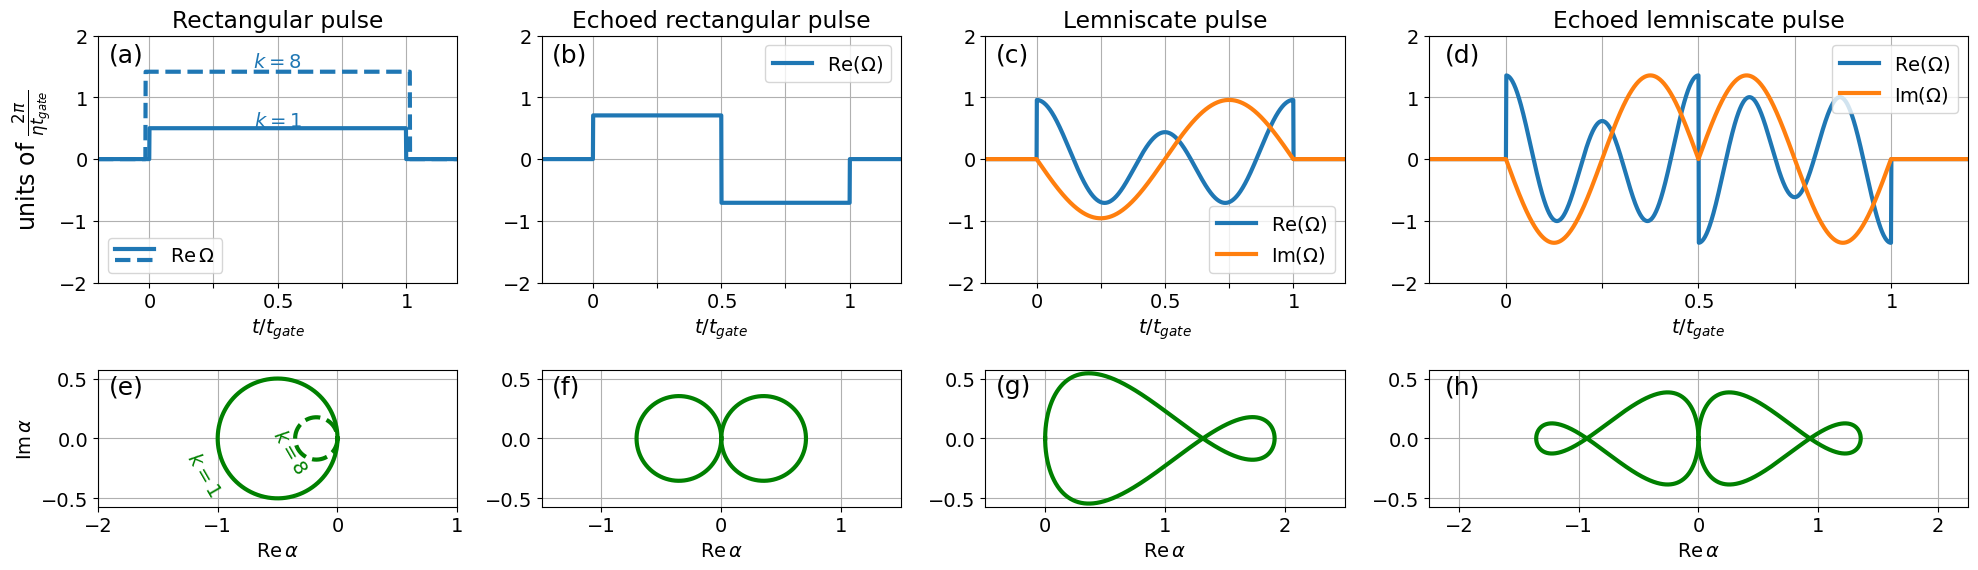

In [40]:
matplotlib.rcParams.update({'font.size' : 14})
fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(20,6), 
                                    gridspec_kw={'width_ratios' : [1,1,1,1.5]})#, 'height_ratios' : [1, 1]})

ax1.set_title('Rectangular pulse')
l1, = ax1.plot(t1, rect_pulse(t1), linestyle='-', linewidth=3, label=r'$\operatorname{Re}(\Omega)/\Omega_{max}$')
dt = 0.015
l8, = ax1.plot(t1, 2*math.sqrt(2)*rect_pulse((t1+dt)/(1 + 2*dt)), linestyle='--', 
               linewidth=3, color='tab:blue', label=' ')
ax1.text(0.5, 1.05*0.5, '$k=1$', horizontalalignment='center', color='tab:blue')
ax1.text(0.5, 1.05*math.sqrt(2), '$k=8$', horizontalalignment='center', color='tab:blue')


#ax5.set_title('Rectangular pulse phase trajectory')
ax5.plot(np.real(res_1), np.imag(res_1), color='g', linewidth=3)
ax5.plot(np.real(res_1)/math.sqrt(8), np.imag(res_1)/math.sqrt(8), color='g', linestyle='--', linewidth=3)

phit5 = np.pi/6
xt5 = 0.6*(-1 + np.cos(np.pi - phit5))
yt5 = -0.6*np.sin(np.pi - phit5)
ax5.text(xt5, yt5, '$k=1$', rotation=-(90 - phit5/np.pi*180), color='g', 
         verticalalignment='center', horizontalalignment='center')
ax5.text(xt5/math.sqrt(8), yt5/math.sqrt(8), '$k=8$', rotation=-(90 - phit5/np.pi*180), color='g',
        verticalalignment='center', horizontalalignment='center')

ax5.set_xlabel(r'$\operatorname{Re}\alpha$')
ax5.set_ylabel(r'$\operatorname{Im}\alpha$')
ax5.set_aspect('equal')

ax2.set_title('Echoed rectangular pulse')
ax2.plot(t1, echoed_rect_pulse(t1), linewidth=3, label=r'$\operatorname{Re}(\Omega)$')

ax2.set_xlabel('$t/t_{gate}$')
ax2.margins(x=0)

#ax6.set_title('Echoed rectangular pulse phase trajectory')
ax6.plot( np.real(res_1)/math.sqrt(2),  np.imag(res_1)/math.sqrt(2), color='g', linewidth=3, label=r'$\operatorname{Re}(\Omega)$')
ax6.plot(-np.real(res_1)/math.sqrt(2), -np.imag(res_1)/math.sqrt(2), color='g', linewidth=3, label=r'$\operatorname{Im}(\Omega)$')
ax6.set_xlabel(r'$\operatorname{Re}\alpha$')
#ax6.set_ylabel(r'$\operatorname{Im}\alpha$')
ax6.set_aspect('equal')

ax3.set_title('Lemniscate pulse')
ax3.plot(t1, lemniscate_pulse(t1).real, linewidth=3, label=r'$\operatorname{Re}(\Omega)$')
ax3.plot(t1, lemniscate_pulse(t1).imag, linewidth=3, label=r'$\operatorname{Im}(\Omega)$')
#ax3.legend()
ax3.margins(x=0)

ax1.set_ylabel(r'units of $\frac{2\pi}{\eta t_{gate}}$', fontsize=17)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-2, 2)
    ax.set_xlabel('$t/t_{gate}$')
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_xticklabels(['$0$', '', '$0.5$', '', '$1$'])
    #ax.set_xticks([0.25, 0.75], minor=True)
    ax.grid()

ax5.set_xlim(-2, 1)
ax6.set_xlim(-1.5, 1.5)
ax7.set_xlim(-0.5, 2.5)
ax8.set_xlim(-2.25, 2.25)

for ax in [ax5, ax6, ax7, ax8]:
    ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    ax.grid()
    ax.set_ylim(-0.57, 0.57)

#ax7.set_title('Lemniscate phase trajectory')
ax7.plot(x_1, y_1, color='g', linewidth=3)
ax7.set_xlabel(r'$\operatorname{Re}\alpha$')
#ax7.set_ylabel(r'$\operatorname{Im}\alpha$')
ax7.set_aspect('equal')


ax4.set_title('Echoed lemniscate pulse')
ax4.plot(t1, echoed_lemniscate_pulse(t1).real, linewidth=3, label=r'$\operatorname{Re}(\Omega)$')
ax4.plot(t1, echoed_lemniscate_pulse(t1).imag, linewidth=3, label=r'$\operatorname{Im}(\Omega)$')
ax4.set_xlabel('$t/t_{gate}$')
ax4.margins(x=0)

#ax8.set_title('Echoed lemniscate phase trajectory')
ax8.plot(x_1/math.sqrt(2),   y_1/math.sqrt(2),   color='g', linewidth=3)
ax8.plot(-x_1/math.sqrt(2), -y_1/math.sqrt(2), color='g', linewidth=3)
ax8.set_xlabel(r'$\operatorname{Re}\alpha$')
#ax8.set_ylabel(r'$\operatorname{Im}\alpha$')
ax8.set_aspect('equal')

subfig_captions = 'abcdefgh'

for letter, ax in zip(subfig_captions, [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]):
    ax.text(0.03, 0.97, f'({letter})', transform=ax.transAxes, verticalalignment='top', fontsize=18)

ax1.legend([(l1, l8)], ['$\operatorname{Re}\Omega$'],
           handlelength=2,
           handler_map={tuple: TupleOfLinesHandler()},
           loc='lower left')

#ax1.legend(loc='lower left')
ax2.legend(loc='upper right')
ax3.legend(loc='lower right')
ax4.legend(loc='upper right')

plt.tight_layout()
#plt.savefig('../figures/phase_trajectories.pdf')
plt.show()